# Poverty Map (Populated Places)

In [ ]:
### NODES (populated places): 
### We collected all nodes in OpenStreetMap that have one of the following tags: 
### ‘city’, ‘town’, ‘village’, ‘hamlet’, or ‘isolated_dwelling’.

In [ ]:
### ROADS: 
### We define roads as 'ways' in OpenStreetMap that have one of the following tags: 'primary', 'primary_link', 'secondary', 'secondary_link', 'tertiary', 'tertiary_link', 'trunk', 'trunk_link', 'motorway'.
### Also collect the surface types of roads to distinguish paved and unpaved roads.

In [ ]:
### JUNCTIONS:
### Our definition of junction is a node in OpenStreetMap where two or more ways cross, or 
### three or more ways begin. This definition includes nodes that don’t count as a typical road
### intersection, such as a road forking to two parallel trunk roads and a link to an overpass. We count
### them as junctions since they reflect a similar concept of man-made structure complexity to a road
### intersection.

In [ ]:
### 24 POIs
### bar, cafe, fast food, pub, college, kindergarten, library, school,
### university, bus station, atm, bank, clinic, dentist, 
### hospital, pharmacy, veterinary, cinema, community centre, 
### courthouse, embassy, marketplace, police, townhall.

## Setup

### Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
!ln -s /content/drive/MyDrive/Colab\ Notebooks/SES-Inference /mydrive

Mounted at /content/drive


### Dependencies

In [ ]:
!pip install OSMPythonTools
!pip install geopandas
!pip install pyshp

In [ ]:
import os
import sys
import pandas as pd
import glob 

sys.path.append('/mydrive/libs/')
%set_env PYTHONPATH=/env/python:/mydrive/libs/

%load_ext autoreload
%autoreload 2

from maps.geoviz import GeoViz
from maps.osm import OSM
from utils import viz
from utils import ios

env: PYTHONPATH=/env/python:/mydrive/libs/
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
CACHE_DIR = '/mydrive/cache'

## Populated Places

### Locations

In [ ]:
fn = '/mydrive/data/Uganda/results/PPLACES.csv'
country = 'UG'
osmppl = OSM()
osmppl.get_populated_places_by_country(country, fn=fn, overwrite=False, cache_dir=CACHE_DIR)
print(osmppl.ppl.shape)

(13902, 12)


In [ ]:
osmppl.ppl.head()

,id,lat,lon,loc_name,name,type,place,population,capital,is_capital,admin_level,GNS:dsg_code
0,104352188,3.566077,31.831003,NaN,Laropi,node,village,NaN,NaN,NaN,NaN,NaN
1,206934045,3.719551,32.747753,NaN,Lapak,node,village,NaN,NaN,NaN,NaN,NaN
2,228783245,3.501842,30.941417,NaN,Kuluba,node,village,NaN,NaN,NaN,NaN,NaN
3,281721577,-1.421437,30.009849,NaN,Katuna,node,town,NaN,NaN,NaN,NaN,NaN
4,292850758,0.091505,32.502320,NaN,Abaita Babiri,node,village,NaN,NaN,NaN,NaN,NaN


In [ ]:
places = osmppl.get_populated_places_id_lat_lon()
len(places)

13902

### OSM Features

* The total length of roads
* distance to the closest road
* number of junctions
* distance to the closest junctions
* total building area
* the number of buildings for each 1 square-mile populated area. 
* the number of and distance to 24 locations of interest such as schools, hospitals, and markets.

#### Example

In [ ]:
osm = OSM()
osm.get_features(places[0:1], fn=None, cache_dir=CACHE_DIR)

100%|██████████| 1/1 [00:02<00:00,  2.62s/it]


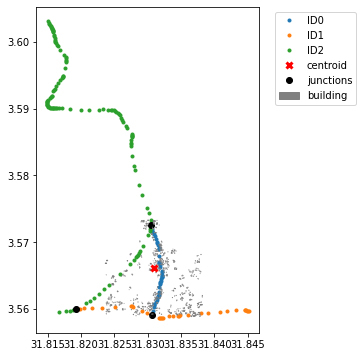

In [ ]:
for i,row in osm.features.iterrows():
  GeoViz.plot_multiple_coords(osm.roads[i], row.lat, row.lon, osm.junctions[i], osm.buildings[i])

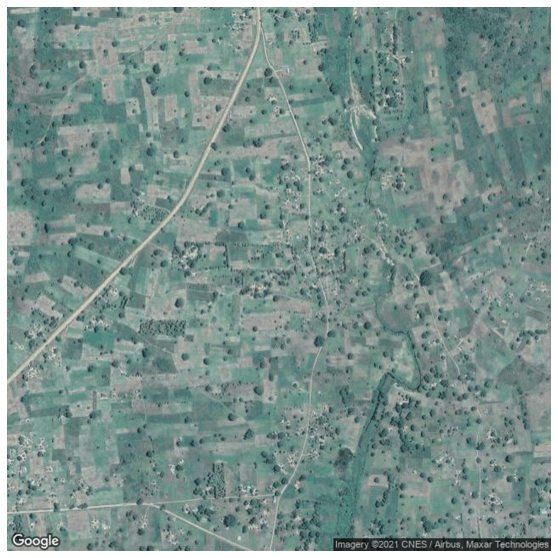

In [ ]:
_p = "/mydrive/data/maps/staticmaps/images/uganda/"
_f = [glob.glob(os.path.join(_p,"OSMID{}-*.png".format(ID))) for ID in osm.features.id]
for _fn in _f:
  viz.imgshow_big(_fn[0])

#### All-in-one

In [ ]:
fn_osm = '/mydrive/data/Uganda/results/PPLACES_OSM.csv'
osm = OSM()
osm.get_features(places, fn=fn_osm, overwrite=True, cache_dir=CACHE_DIR)

100%|█████████▉| 13898/13902 [7:47:16<00:10,  2.56s/it][overpass] downloading data: [timeout:2][out:json];(way['building'='yes'](2.5167687189192556,30.799235026403274,2.53121164095957,30.813691973596725);); out body geom;
[overpass] downloading data: [timeout:2][out:json];(node['amenity'~'bar|cafe|fast_food|pub|college|kindergarten|library|school|university|bus_station|atm|bank|clinic|dentist|hospital|pharmacy|veterinari|cinema|community_centre|courthouse|embassy|marketplace|police|townhall'](2.5167687189192556,30.799235026403274,2.53121164095957,30.813691973596725);); out body geom;
100%|█████████▉| 13901/13902 [7:47:25<00:02,  2.65s/it][overpass] downloading data: [timeout:2][out:json];(way['highway'~'primary|primary_link|secondary|secondary_link|tertiary|tertiary_link|trunk|trunk_link|motorway'](2.470630865293967,30.861441726403278,2.485074295316416,30.87589867359672);); out body geom;
[overpass] downloading data: [timeout:2][out:json];(way['building'='yes'](2.470630865293967,30.861

In [ ]:
fn_dhs_new = '/mydrive/data/Uganda/results/PPLACES_OSM.csv'
ios.save_csv(osm.features, fn_dhs_new)

/mydrive/data/Uganda/results/PPLACES_OSM.csv saved!


In [ ]:
len(osm.features)

13902

In [ ]:
osm.features.head()

,id,lat,lon,total_length_roads,distance_closest_road,num_junctions,distance_closest_junction,total_building_area,num_buildings,bar,bar_dist,cafe,cafe_dist,fast_food,fast_food_dist,pub,pub_dist,college,college_dist,kindergarten,kindergarten_dist,library,library_dist,school,school_dist,university,university_dist,bus_station,bus_station_dist,atm,atm_dist,bank,bank_dist,clinic,clinic_dist,dentist,dentist_dist,hospital,hospital_dist,pharmacy,pharmacy_dist,veterinari,veterinari_dist,cinema,cinema_dist,community_centre,community_centre_dist,courthouse,courthouse_dist,embassy,embassy_dist,marketplace,marketplace_dist,police,police_dist,townhall,townhall_dist
0,104352188,3.566077,31.831003,11468.113022,102.376568,3,713.033922,16580.502937,848,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1003.806235,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,206934045,3.719551,32.747753,49422.876518,40.650290,3,50.775798,6799.789986,346,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,411.023944,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,228783245,3.501842,30.941417,23536.820550,114.335331,5,124.804447,62965.041523,1924,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,57.520875,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,281721577,-1.421437,30.009849,66743.296096,46.563861,6,176.127537,47361.844322,980,0,0,0,0,0,0,0,0,0,0,1,563.864,0,0,1,536.915145,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,292850758,0.091505,32.502320,15500.829138,174.956687,30,328.515933,196086.824614,2539,3,285.07,1,438.468,7,688.984,0,0,0,0,0,0,1,714.036,0,0.000000,3,574.888,0,0,2,374.29,2,273.521,2,658.764,0,0,0,0,1,555.292,0,0,0,0,0,0,0,0,0,0,1,314.812,1,368.966,0,0


In [5]:
import pandas as pd
df = pd.DataFrame({'A':[1,2,3],'B':[1,2,3]})
df

,A,B
0,1,1
1,2,2
2,3,3


In [7]:
df.rename(columns={'C':'D'}, inplace=True)
df

,A,B
0,1,1
1,2,2
2,3,3


In [19]:
%cd /mydrive/data/Sierra Leone/results/staticmaps
!ls clusters/Y*.png | wc -lc 

/content/drive/MyDrive/Colab Notebooks/SES-Inference/data/Sierra Leone/results/staticmaps
    893   69180


In [ ]:
OSMID2229102811-LA1.166667-LO34.35-ZO16-SC1-640x640-satellite
Y2016-C1-U2    -LA7.886692-LO-10.621199-ZO16-SC1-640x640-satellite.png